In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [5]:
img = cv2.imread("2.jpg")
print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(1600, 1200, 3)


Image type: <class 'numpy.ndarray'>
Image shape: (1600, 1200, 3)


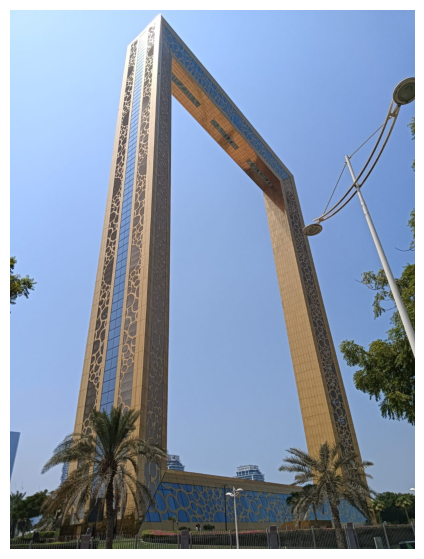

In [10]:
# Check if image was loaded successfully
if img is None:
    print("Error: Image not found. Check the file name/path.")
else:
    print("Image type:", type(img))
    print("Image shape:", img.shape)

    # OpenCV uses BGR, Matplotlib uses RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display image
    plt.figure(figsize=(10, 7))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

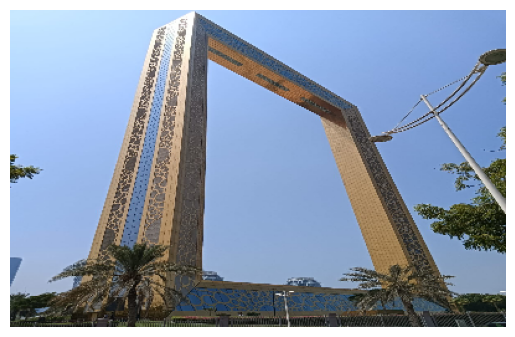

Resized image shape: (256, 400, 3)


In [19]:
# Resize image: width = 400, height = 256
img_resize = cv2.resize(img, (400, 256))

# Display resized image
plt.imshow(cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Check the new size
print("Resized image shape:", img_resize.shape)

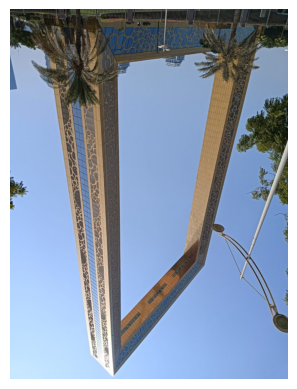

In [23]:
img_flip = cv2.flip(img, 0)  # 0 for vertical, 1 for horizontal, -1 for both
plt.imshow(cv2.cvtColor(img_flip, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

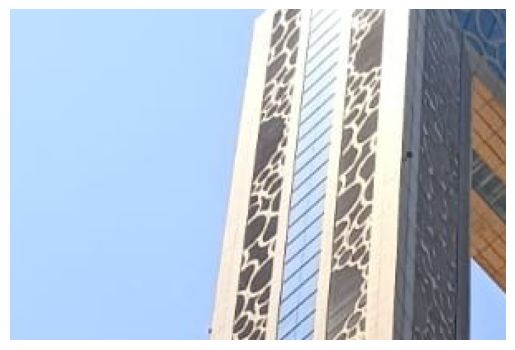

In [22]:
img_cropped = img[100:300, 200:500]

plt.imshow(cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [27]:
import sys
print(sys.version)
print(sys.platform)

3.14.2 (main, Aug 25 2026, 05:50:55) [Clang 23.0.0git (https:/github.com/llvm/llvm-project e5927fecf8a6ce89e1a4eac5b8
emscripten


In [28]:
import cv2
print(cv2.__version__)

4.11.0


In [30]:
import cv2

cap = cv2.VideoCapture(0)

print("Camera opened:", cap.isOpened())

cap.release()

Camera opened: False


In [32]:
from IPython.display import display, Javascript

display(Javascript("""
navigator.mediaDevices.getUserMedia({video: true})
    .then(stream => {
        alert("Webcam access granted!");
        stream.getTracks().forEach(track => track.stop());
    })
    .catch(error => {
        alert("Webcam access failed: " + error);
        console.log(error);
    });
"""))

<IPython.core.display.Javascript object>

In [39]:
from IPython.display import HTML, display

display(HTML("""
<div>
    <video id="webcam" width="640" height="480" autoplay playsinline
           style="border: 2px solid black;"></video>

    <br><br>

    <button onclick="startCamera()">Start Camera</button>
    <button onclick="stopCamera()">Stop Camera</button>

    <p id="status">Camera is stopped.</p>
</div>

<script>
let stream = null;

async function startCamera() {
    try {
        stream = await navigator.mediaDevices.getUserMedia({
            video: true,
            audio: false
        });

        const video = document.getElementById("webcam");
        video.srcObject = stream;

        document.getElementById("status").innerText =
            "Camera is working!";
    }
    catch (error) {
        document.getElementById("status").innerText =
            "Camera error: " + error.message;
        console.error(error);
    }
}

function stopCamera() {
    if (stream) {
        stream.getTracks().forEach(track => track.stop());
        stream = null;
    }

    document.getElementById("webcam").srcObject = null;

    document.getElementById("status").innerText =
        "Camera is stopped.";
}
</script>
"""))

In [43]:
# Provided text
text = """
My hobbies are listening to music, watching movies, reading books, and spending time with my friends and family. I also enjoy learning new things, exploring new places, and trying out creative activities. These hobbies help me relax, stay positive, and make my free time enjoyable.
"""
print(text)


My hobbies are listening to music, watching movies, reading books, and spending time with my friends and family. I also enjoy learning new things, exploring new places, and trying out creative activities. These hobbies help me relax, stay positive, and make my free time enjoyable.



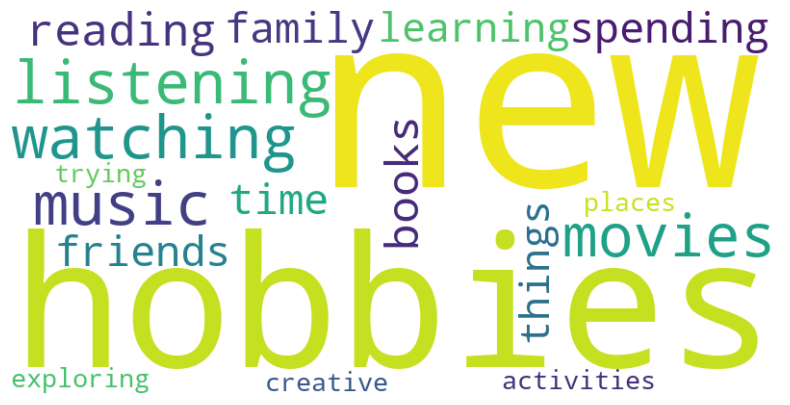

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
My hobbies are listening to music, watching movies, reading books,
spending time with my friends and family, learning new things,
exploring new places, and trying creative activities.
"""

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Tokens:
['my', 'hobbies', 'are', 'listening', 'to', 'music', 'watching', 'movies', 'reading', 'books', 'spending', 'time', 'with', 'my', 'friends', 'and', 'family', 'learning', 'new', 'things', 'exploring', 'new', 'places', 'and', 'trying', 'creative', 'activities']

Tokens after removing stopwords:
['hobbies', 'listening', 'music', 'watching', 'movies', 'reading', 'books', 'spending', 'time', 'friends', 'family', 'learning', 'things', 'exploring', 'places', 'trying', 'creative', 'activities']

Word Frequencies:
Counter({'hobbies': 1, 'listening': 1, 'music': 1, 'watching': 1, 'movies': 1, 'reading': 1, 'books': 1, 'spending': 1, 'time': 1, 'friends': 1, 'family': 1, 'learning': 1, 'things': 1, 'exploring': 1, 'places': 1, 'trying': 1, 'creative': 1, 'activities': 1})


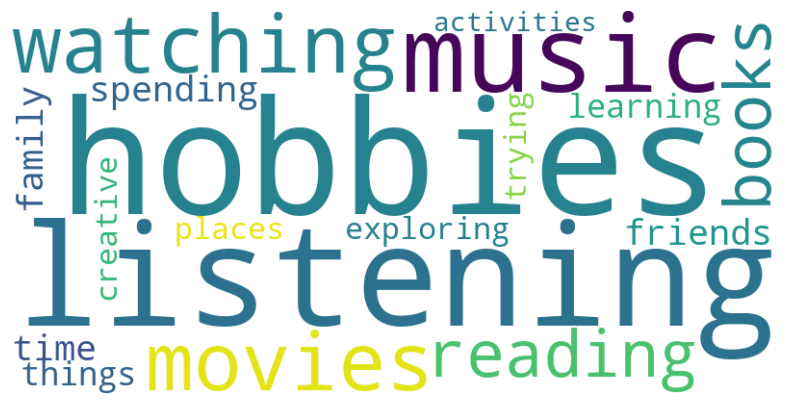

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from collections import Counter

# Provided text
text = """
My hobbies are listening to music, watching movies, reading books,
spending time with my friends and family, learning new things,
exploring new places, and trying creative activities.
"""

# Tokenization
tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())

print("Tokens:")
print(tokens)

# Remove common stopwords manually
stop_words = {
    "my", "are", "to", "and", "with", "new", "my"
}

tokens = [word for word in tokens if word not in stop_words]

print("\nTokens after removing stopwords:")
print(tokens)

# Count word frequency
word_counts = Counter(tokens)

print("\nWord Frequencies:")
print(word_counts)

# Create text from tokens
processed_text = " ".join(tokens)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(processed_text)

# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [49]:
plt.imsave("hobby.png",wordcloud)